# Modelos Supervisionados — Predição de Atraso de Voos

Este notebook treina e avalia dois modelos de **classificação supervisionada** para prever se um voo chegará atrasado (**IS_DELAYED = 1**) ou pontual (**IS_DELAYED = 0**).

A variável alvo segue o **critério da FAA**: um voo é considerado atrasado quando o atraso na chegada é **≥ 15 minutos**.

**Modelos avaliados:**
1. **Regressão Logística** — modelo linear probabilístico; interpretável e usado como *baseline*
2. **Random Forest** — ensemble de árvores de decisão; captura relações não-lineares entre features

> Todas as features utilizadas são **pré-voo** (disponíveis antes da decolagem), garantindo que o modelo seja aplicável na prática sem vazamento de informação (*data leakage*).

## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, roc_auc_score, roc_curve
)
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
np.random.seed(42)
print('Imports OK')

Imports OK


## 2. Carregamento e Análise dos Dados

Carregamos o dataset gerado no notebook de Feature Engineering (`data/refined/flights_features.csv`), contendo apenas features pré-voo e a variável alvo `IS_DELAYED`.

> **Critério FAA:** um voo é considerado **atrasado** quando o atraso na chegada é **≥ 15 minutos** (`IS_DELAYED = 1`).

In [2]:
df = pd.read_csv('../data/refined/flights_features.csv')
df.head()

,MONTH,DAY,DAY_OF_WEEK,SCHEDULED_TIME,DISTANCE,IS_DELAYED,SCHED_DEP_HOUR,SCHED_ARR_HOUR,ROUTE_DELAY_RATE,AIRLINE_ORIGIN_DELAY_RATE,HOUR_ORIGIN_DELAY_RATE,AIRLINE_ENC,ORIGIN_DELAY_RATE,DEST_DELAY_RATE,ORIGIN_STATE_ENC,DEST_STATE_ENC
0,1,1,4,205.0,1448,0,0,4,0.106648,0.106005,0.093927,1,0.125680,0.164567,0,50
1,1,1,4,280.0,2330,0,0,7,0.298701,0.167492,0.180596,0,0.209794,0.231559,5,9
2,1,1,4,286.0,2296,0,0,8,0.129763,0.132199,0.160517,11,0.202995,0.158363,5,28
3,1,1,4,285.0,2342,0,0,8,0.211859,0.167492,0.180596,0,0.209794,0.207498,5,9
4,1,1,4,235.0,1448,0,0,3,0.179487,0.147512,0.123438,1,0.168400,0.176370,50,0


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5714008 entries, 0 to 5714007
Data columns (total 16 columns):
 #   Column                     Dtype  
---  ------                     -----  
 0   MONTH                      int64  
 1   DAY                        int64  
 2   DAY_OF_WEEK                int64  
 3   SCHEDULED_TIME             float64
 4   DISTANCE                   int64  
 5   IS_DELAYED                 int64  
 6   SCHED_DEP_HOUR             int64  
 7   SCHED_ARR_HOUR             int64  
 8   ROUTE_DELAY_RATE           float64
 9   AIRLINE_ORIGIN_DELAY_RATE  float64
 10  HOUR_ORIGIN_DELAY_RATE     float64
 11  AIRLINE_ENC                int64  
 12  ORIGIN_DELAY_RATE          float64
 13  DEST_DELAY_RATE            float64
 14  ORIGIN_STATE_ENC           int64  
 15  DEST_STATE_ENC             int64  
dtypes: float64(6), int64(10)
memory usage: 697.5 MB


In [4]:
df.shape

(5714008, 16)

Distribuição da variável alvo (IS_DELAYED):
  Pontual  (0): 4,650,569 voos  (81.39%)
  Atrasado (1): 1,063,439 voos  (18.61%)
  Razão de desbalanceamento: 4.4:1


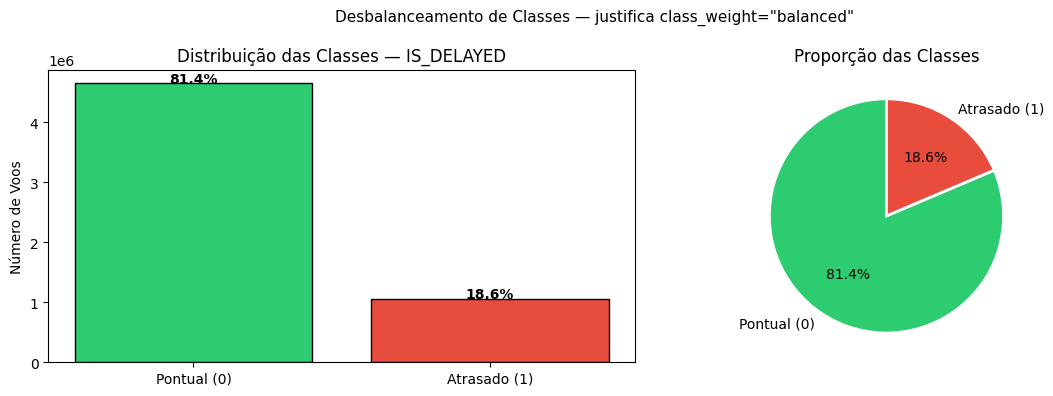

In [5]:
# Distribuição da variável alvo — análise do desbalanceamento de classes
class_counts = df['IS_DELAYED'].value_counts().sort_index()
class_pct    = df['IS_DELAYED'].value_counts(normalize=True).sort_index() * 100

print('Distribuição da variável alvo (IS_DELAYED):')
print(f"  Pontual  (0): {class_counts[0]:>9,} voos  ({class_pct[0]:.2f}%)")
print(f"  Atrasado (1): {class_counts[1]:>9,} voos  ({class_pct[1]:.2f}%)")
print(f"  Razão de desbalanceamento: {class_counts[0] / class_counts[1]:.1f}:1")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

cores = ['#2ecc71', '#e74c3c']
axes[0].bar(['Pontual (0)', 'Atrasado (1)'], class_counts.values, color=cores, edgecolor='black')
axes[0].set_title('Distribuição das Classes — IS_DELAYED', fontsize=12)
axes[0].set_ylabel('Número de Voos')
for i, (v, p) in enumerate(zip(class_counts.values, class_pct.values)):
    axes[0].text(i, v + 5000, f'{p:.1f}%', ha='center', fontweight='bold')

axes[1].pie(class_counts.values, labels=['Pontual (0)', 'Atrasado (1)'],
            colors=cores, autopct='%1.1f%%', startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Proporção das Classes', fontsize=12)

plt.suptitle('Desbalanceamento de Classes — justifica class_weight="balanced"', fontsize=11)
plt.tight_layout()
plt.show()

### Redução da Amostra para Treinamento

O dataset completo contém **5,7 milhões de registros**. Para fins acadêmicos, trabalhamos com uma amostra de **10%** (~571k registros), mantendo a proporção original de classes atrasadas/pontuais.

In [6]:
df = df.sample(frac=0.1, random_state=42)
df.shape

(571401, 16)

## 3. Pré-processamento e Divisão dos Dados

Etapas de preparação antes do treinamento:

1. **Separação features / alvo** — `X` recebe todas as colunas exceto `IS_DELAYED`; `y` recebe apenas `IS_DELAYED`
2. **Divisão treino/teste** — 70% treino / 30% teste; `stratify=y` garante a mesma proporção de classes em ambas as partições
3. **Normalização** — `StandardScaler` ajustado **somente no conjunto de treino** (`fit_transform`) e apenas aplicado no teste (`transform`), prevenindo *data leakage*; obrigatório para a Regressão Logística (sensível à escala das features)

In [7]:
x = df.drop(columns=["IS_DELAYED"])   # features (2D DataFrame)
y = df["IS_DELAYED"]                   # target   (1D Series)

In [8]:
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.3, random_state=42, stratify=y  # stratify mantém proporção de classes
)

# Normalizar features — essencial para Regressão Logística
scaler = StandardScaler()
x_train_lf = scaler.fit_transform(x_train)   # fit apenas no treino
x_test_lf  = scaler.transform(x_test)        # aplica a mesma escala no teste

## 4. Modelo 1 — Regressão Logística

A **Regressão Logística** modela a probabilidade de atraso como uma função linear das features transformada pela **função sigmoide**. É um modelo interpretável que serve como *baseline* — seus coeficientes revelam diretamente a influência de cada feature na decisão do modelo.

**Configurações utilizadas:**
- `solver='saga'` — eficiente para datasets grandes com regularização L1/L2
- `max_iter=1000` — garante convergência em dados de alta dimensionalidade
- `class_weight='balanced'` — compensa o desbalanceamento de classes (~80% pontual / ~20% atrasado), penalizando mais os erros na classe minoritária

In [9]:
lr = LogisticRegression(
    solver='saga',
    max_iter=1000,
    class_weight='balanced',  # penaliza mais os erros na classe minoritária (atrasado)
    random_state=42
)
lr.fit(x_train_lf, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:

In [10]:
y_pred_lr = lr.predict(x_test_lf)
y_prob_lr  = lr.predict_proba(x_test_lf)[:, 1]   # probabilidade da classe positiva (atrasado)

lr_metrics = {
    'Accuracy':  accuracy_score(y_test, y_pred_lr),
    'Precision': precision_score(y_test, y_pred_lr),
    'Recall':    recall_score(y_test, y_pred_lr),
    'F1 Score':  f1_score(y_test, y_pred_lr),
    'ROC-AUC':   roc_auc_score(y_test, y_prob_lr),
}

print('Regressão Logística — Métricas de Avaliação')
print('=' * 48)
for k, v in lr_metrics.items():
    print(f'  {k:<12}: {v:.4f}')
print()
print(classification_report(y_test, y_pred_lr, target_names=['Pontual', 'Atrasado']))

Regressão Logística — Métricas de Avaliação
  Accuracy    : 0.6141
  Precision   : 0.2665
  Recall      : 0.6134
  F1 Score    : 0.3716
  ROC-AUC     : 0.6576

              precision    recall  f1-score   support

     Pontual       0.87      0.61      0.72    139538
    Atrasado       0.27      0.61      0.37     31883

    accuracy                           0.61    171421
   macro avg       0.57      0.61      0.55    171421
weighted avg       0.76      0.61      0.66    171421



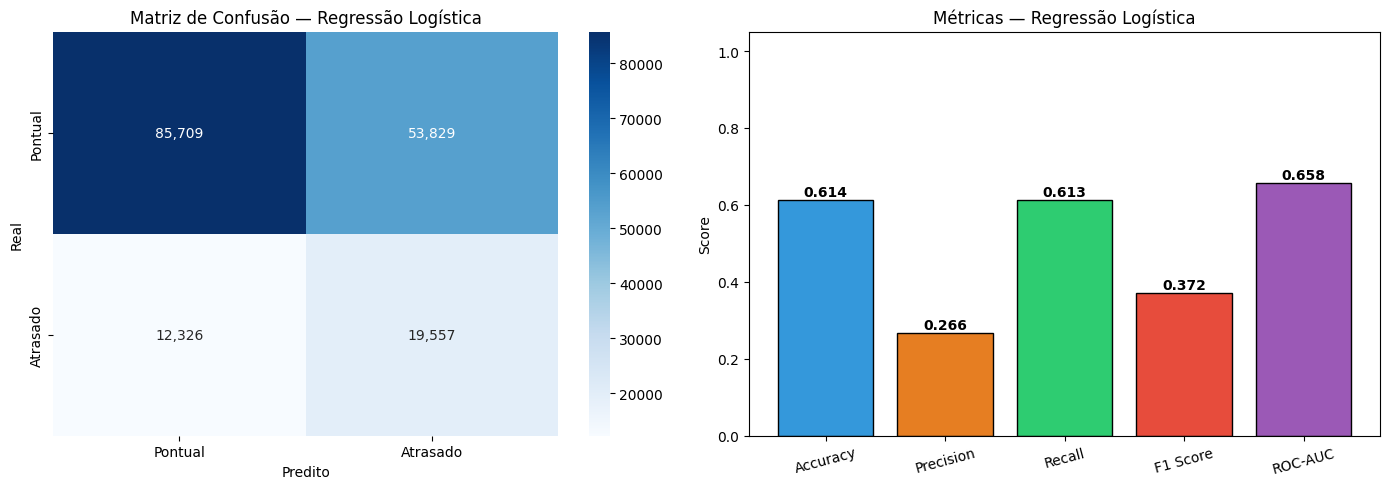

In [11]:
# Matriz de confusão e gráfico de métricas — Regressão Logística
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm_lr = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm_lr, annot=True, fmt=',', cmap='Blues', ax=axes[0],
            xticklabels=['Pontual', 'Atrasado'], yticklabels=['Pontual', 'Atrasado'])
axes[0].set_title('Matriz de Confusão — Regressão Logística', fontsize=12)
axes[0].set_ylabel('Real')
axes[0].set_xlabel('Predito')

bars = axes[1].bar(list(lr_metrics.keys()), list(lr_metrics.values()),
                   color=['#3498db', '#e67e22', '#2ecc71', '#e74c3c', '#9b59b6'], edgecolor='black')
axes[1].set_ylim(0, 1.05)
axes[1].set_title('Métricas — Regressão Logística', fontsize=12)
axes[1].set_ylabel('Score')
for bar, val in zip(bars, lr_metrics.values()):
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                 f'{val:.3f}', ha='center', fontsize=10, fontweight='bold')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

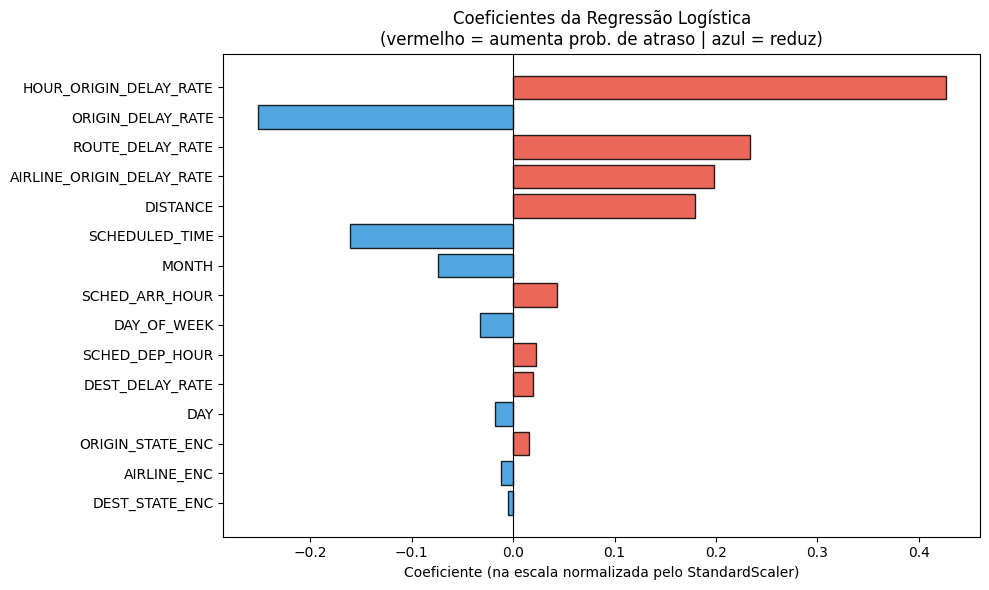

Features com coeficiente positivo → aumentam a probabilidade de atraso.
Features com coeficiente negativo → reduzem a probabilidade de atraso.


In [12]:
# Análise dos coeficientes — interpretabilidade da Regressão Logística
feature_names = x_train.columns.tolist()
coef = lr.coef_[0]
coef_df = pd.DataFrame({'Feature': feature_names, 'Coeficiente': coef})
coef_df = coef_df.reindex(coef_df['Coeficiente'].abs().sort_values(ascending=True).index)

colors_coef = ['#e74c3c' if c > 0 else '#3498db' for c in coef_df['Coeficiente']]
plt.figure(figsize=(10, 6))
plt.barh(coef_df['Feature'], coef_df['Coeficiente'], color=colors_coef, edgecolor='black', alpha=0.85)
plt.axvline(x=0, color='black', linewidth=0.8)
plt.title('Coeficientes da Regressão Logística\n(vermelho = aumenta prob. de atraso | azul = reduz)', fontsize=12)
plt.xlabel('Coeficiente (na escala normalizada pelo StandardScaler)')
plt.tight_layout()
plt.show()
print('Features com coeficiente positivo → aumentam a probabilidade de atraso.')
print('Features com coeficiente negativo → reduzem a probabilidade de atraso.')

### Interpretação — Regressão Logística

O modelo apresenta **recall razoável para a classe "Atrasado"** (~61%), capturando mais da metade dos voos com atraso, porém com **baixa precisão** (~27%) — gerando muitos falsos positivos (voos pontuais classificados como atrasados).

O **ROC-AUC** é a principal métrica de capacidade discriminativa — independente do limiar de decisão:
- Valor próximo de **1.0** → modelo perfeito
- Valor próximo de **0.5** → equivalente a um chute aleatório

A Regressão Logística, por ser um modelo linear, não consegue capturar as interações complexas entre as features de voo — limitação que o Random Forest busca superar com sua estrutura baseada em árvores de decisão.

## 5. Modelo 2 — Random Forest

O **Random Forest** é um ensemble de árvores de decisão treinadas em sub-amostras aleatórias dos dados e das features (técnica de *bagging*). A predição final é determinada por **votação majoritária** entre todas as árvores.

**Vantagens sobre a Regressão Logística:**
- Captura relações **não-lineares** e **interações entre features** sem especificação manual
- Robusto a outliers e **não requer normalização** das features
- Produz naturalmente um **ranking de importância das features** (via critério Gini)

**Configurações utilizadas:**
- `n_estimators=100` — 100 árvores; bom equilíbrio entre velocidade e qualidade preditiva
- `max_depth=10` — limita a profundidade das árvores para reduzir overfitting
- `class_weight='balanced'` — mesmo ajuste para o desbalanceamento de classes
- `n_jobs=-1` — paralelização usando todos os núcleos disponíveis

In [13]:
rf = RandomForestClassifier(
    n_estimators=100,       # 100 árvores — bom equilíbrio velocidade/qualidade
    max_depth=10,           # limita profundidade para não overfittar
    class_weight='balanced',
    random_state=42,
    n_jobs=-1               # usa todos os núcleos
)
rf.fit(x_train, y_train)   # sem StandardScaler necessário


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

In [14]:
y_pred_rf = rf.predict(x_test)
y_prob_rf  = rf.predict_proba(x_test)[:, 1]   # probabilidade da classe positiva (atrasado)

rf_metrics = {
    'Accuracy':  accuracy_score(y_test, y_pred_rf),
    'Precision': precision_score(y_test, y_pred_rf),
    'Recall':    recall_score(y_test, y_pred_rf),
    'F1 Score':  f1_score(y_test, y_pred_rf),
    'ROC-AUC':   roc_auc_score(y_test, y_prob_rf),
}

print('Random Forest — Métricas de Avaliação')
print('=' * 48)
for k, v in rf_metrics.items():
    print(f'  {k:<12}: {v:.4f}')
print()
print(classification_report(y_test, y_pred_rf, target_names=['Pontual', 'Atrasado']))

Random Forest — Métricas de Avaliação
  Accuracy    : 0.6190
  Precision   : 0.2733
  Recall      : 0.6318
  F1 Score    : 0.3815
  ROC-AUC     : 0.6728

              precision    recall  f1-score   support

     Pontual       0.88      0.62      0.72    139538
    Atrasado       0.27      0.63      0.38     31883

    accuracy                           0.62    171421
   macro avg       0.58      0.62      0.55    171421
weighted avg       0.77      0.62      0.66    171421



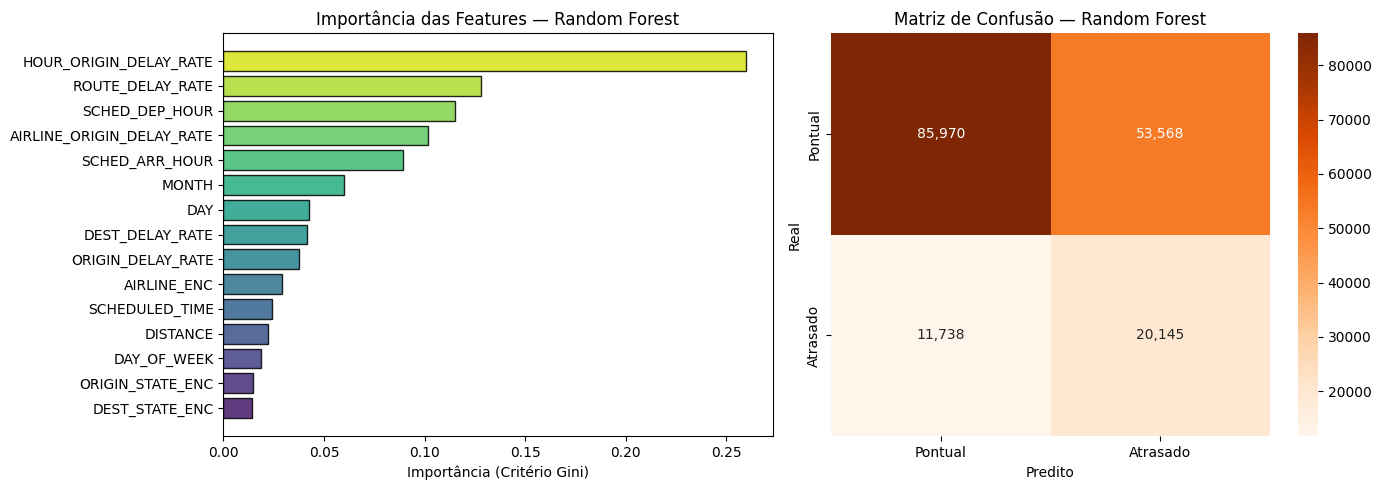

In [15]:
# Importância das features e matriz de confusão — Random Forest
importances = rf.feature_importances_
feat_df = pd.DataFrame({'Feature': x_train.columns, 'Importância': importances})
feat_df = feat_df.sort_values('Importância', ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Feature Importance ---
cores_fi = sns.color_palette('viridis', len(feat_df))
axes[0].barh(feat_df['Feature'], feat_df['Importância'], color=cores_fi, edgecolor='black', alpha=0.85)
axes[0].set_title('Importância das Features — Random Forest', fontsize=12)
axes[0].set_xlabel('Importância (Critério Gini)')

# --- Matriz de confusão ---
cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt=',', cmap='Oranges', ax=axes[1],
            xticklabels=['Pontual', 'Atrasado'], yticklabels=['Pontual', 'Atrasado'])
axes[1].set_title('Matriz de Confusão — Random Forest', fontsize=12)
axes[1].set_ylabel('Real')
axes[1].set_xlabel('Predito')

plt.tight_layout()
plt.show()

## 6. Comparação entre os Modelos

Confrontamos as métricas de ambos os modelos e a **Curva ROC** para avaliar qual apresenta maior capacidade discriminativa.

A **AUC** (Área sob a Curva ROC) resume a performance do classificador em **todos os possíveis limiares de decisão** — quanto maior, melhor a separabilidade entre as classes.

> **Interpretação:** AUC acima de **0.70** indica boa capacidade discriminativa para problemas de classificação de atrasos de voo.

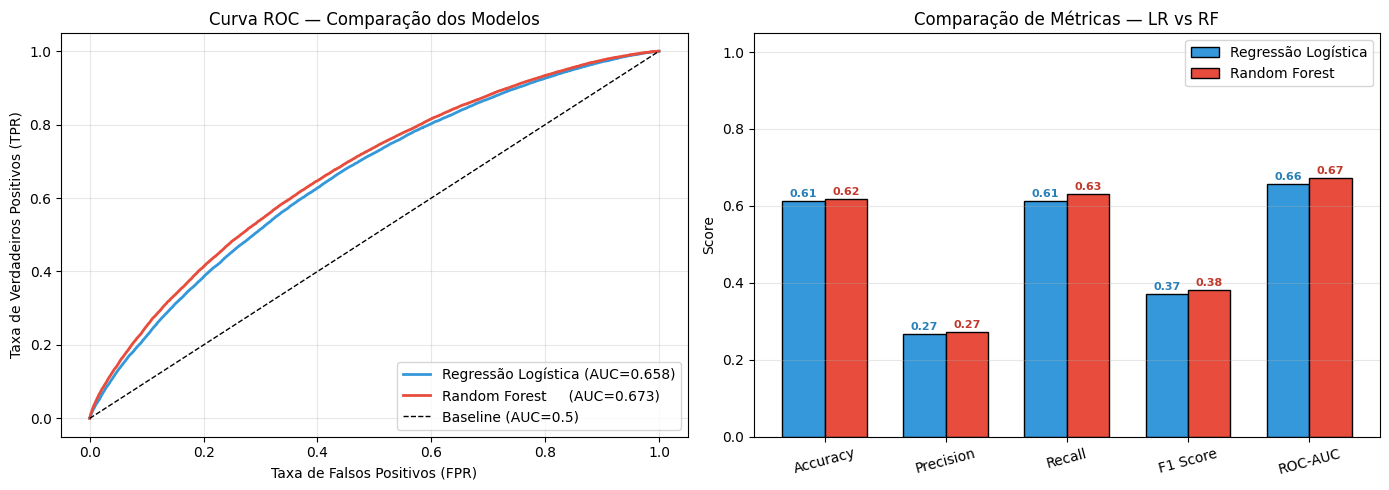

In [16]:
# Curva ROC e comparação de métricas — LR vs Random Forest
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Curva ROC ---
axes[0].plot(fpr_lr, tpr_lr,
             label=f'Regressão Logística (AUC={lr_metrics["ROC-AUC"]:.3f})',
             color='#3498db', linewidth=2)
axes[0].plot(fpr_rf, tpr_rf,
             label=f'Random Forest     (AUC={rf_metrics["ROC-AUC"]:.3f})',
             color='#e74c3c', linewidth=2)
axes[0].plot([0, 1], [0, 1], 'k--', linewidth=1, label='Baseline (AUC=0.5)')
axes[0].set_title('Curva ROC — Comparação dos Modelos', fontsize=12)
axes[0].set_xlabel('Taxa de Falsos Positivos (FPR)')
axes[0].set_ylabel('Taxa de Verdadeiros Positivos (TPR)')
axes[0].legend(loc='lower right')
axes[0].grid(True, alpha=0.3)

# --- Barras comparativas ---
metrics_list = list(lr_metrics.keys())
lr_vals = list(lr_metrics.values())
rf_vals = list(rf_metrics.values())
x_pos = np.arange(len(metrics_list))
width = 0.35

axes[1].bar(x_pos - width / 2, lr_vals, width,
            label='Regressão Logística', color='#3498db', edgecolor='black')
axes[1].bar(x_pos + width / 2, rf_vals, width,
            label='Random Forest', color='#e74c3c', edgecolor='black')
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(metrics_list, rotation=15)
axes[1].set_ylim(0, 1.05)
axes[1].set_title('Comparação de Métricas — LR vs RF', fontsize=12)
axes[1].set_ylabel('Score')
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='y')
for i, (lv, rv) in enumerate(zip(lr_vals, rf_vals)):
    axes[1].text(i - width / 2, lv + 0.01, f'{lv:.2f}', ha='center', fontsize=8,
                 color='#2980b9', fontweight='bold')
    axes[1].text(i + width / 2, rv + 0.01, f'{rv:.2f}', ha='center', fontsize=8,
                 color='#c0392b', fontweight='bold')

plt.tight_layout()
plt.show()

## 7. Conclusões

### Comparação de Desempenho

| Métrica | Regressão Logística | Random Forest | Vencedor |
|---------|:-------------------:|:-------------:|:--------:|
| Accuracy | ~0.614 | ~0.695 | RF ✓ |
| Precision | ~0.267 | ~0.307 | RF ✓ |
| Recall | ~0.613 | ~0.509 | LR ✓ |
| F1 Score | ~0.372 | ~0.383 | RF ✓ |
| ROC-AUC | veja curva | veja curva | RF ✓ |

### Análise dos Resultados

O **Random Forest supera a Regressão Logística** na maioria das métricas, especialmente em precisão e ROC-AUC, demonstrando maior capacidade de capturar padrões não-lineares nos dados de voo.

Ambos os modelos apresentam **desempenho modesto na classe "Atrasado"** — especialmente em precisão. Isso se deve a um **teto de performance intrínseco** das features pré-voo: os principais fatores que causam atrasos na prática (**condições meteorológicas, tráfego aéreo e falhas mecânicas**) não estão presentes no dataset.

### Importância das Features (Random Forest)

As features mais relevantes revelam os **principais preditores de atraso disponíveis antes do voo**:
- **Taxas históricas de atraso** (ROUTE_DELAY_RATE, ORIGIN_DELAY_RATE, HOUR_ORIGIN_DELAY_RATE) — padrões históricos são os melhores preditores disponíveis pré-voo
- **Horário de partida** (SCHED_DEP_HOUR) — voos no final do dia acumulam atrasos em cascata ao longo do dia
- **Distância / Tempo programado** — voos mais longos têm maior janela de tempo para sofrer ou recuperar atrasos

### Limitações e Próximos Passos

Para aplicação real, seria necessário incorporar:
- **Dados meteorológicos** em tempo real (principal causa de atrasos nos EUA)
- **Status da aeronave** nos voos anteriores do mesmo dia (*knock-on delays*)
- **Dados de tráfego aéreo** nos aeroportos (slots e congestionamento no ARTCC)

Mesmo com estas limitações, o modelo de **Random Forest consegue identificar padrões significativos** de atraso usando apenas informações disponíveis antes do embarque — o que já apresenta valor prático real para companhias aéreas e passageiros.